In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
def trade(X,Y):
    X_hist = np.zeros((t_max+1,M))
    Y_hist = np.zeros((t_max+1,M*2))
    memory_index_x = 0
    memory_index_y = 0
    
    for t in range(t_max):
        X_hist[t] = X
        Y_hist[t] = Y
        prod_x_want = np.random.choice(X)
        prod_y_want = np.random.choice(Y)

        memory_index_x = np.random.randint(M)
        X[memory_index_x] = prod_y_want
        

        memory_index_y = np.random.randint(M*2)
        Y[memory_index_y] = prod_x_want
        '''
        
        X[memory_index_x] = prod_y_want
        memory_index_x = (memory_index_x + 1) % M


        Y[memory_index_y] = prod_x_want
        memory_index_y = (memory_index_y + 1) % M
        '''

    X_hist[-1] = X
    Y_hist[-1] = Y

    return X_hist, Y_hist

def dx_dt(x, y):
    return y * (1 - x) - x * (1 - y)

def dy_dt(x, y):
    return x * (1 - y) - y * (1 - x)


def runge_kutta4(x0, y0, t0, t_final, h):
    t_values = np.arange(t0, t_final, h)
    x_values = np.zeros(len(t_values))
    y_values = np.zeros(len(t_values))
    
    x_values[0], y_values[0] = x0, y0
    
    for i in range(1, len(t_values)):
        t = t_values[i-1]
        x, y = x_values[i-1], y_values[i-1]

        k1_x = h * dx_dt(x, y)
        k1_y = h * dy_dt(x, y)

        k2_x = h * dx_dt(x + 0.5 * k1_x, y + 0.5 * k1_y)
        k2_y = h * dy_dt(x + 0.5 * k1_x, y + 0.5 * k1_y)

        k3_x = h * dx_dt(x + 0.5 * k2_x, y + 0.5 * k2_y)
        k3_y = h * dy_dt(x + 0.5 * k2_x, y + 0.5 * k2_y)

        k4_x = h * dx_dt(x + k3_x, y + k3_y)
        k4_y = h * dy_dt(x + k3_x, y + k3_y)

        x_values[i] = x + (1/6) * (k1_x + 2*k2_x + 2*k3_x + k4_x)
        y_values[i] = y + (1/6) * (k1_y + 2*k2_y + 2*k3_y + k4_y)
    
    return t_values, x_values, y_values

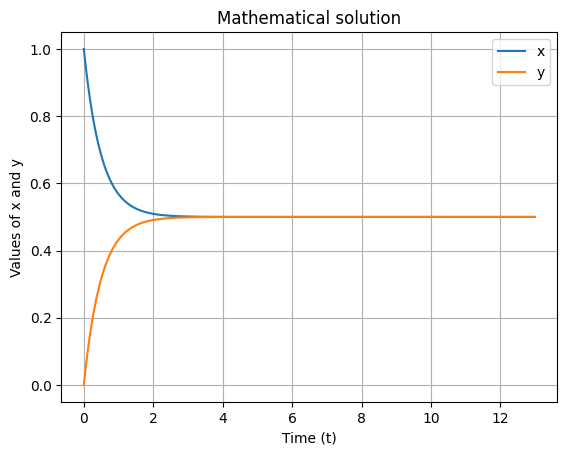

In [98]:
x0, y0 = 1, 0  
t0, t_final, h = 0, 13, 0.01  


t_vals, x_vals, y_vals = runge_kutta4(x0, y0, t0, t_final, h)


plt.plot(t_vals, x_vals, label='x')
plt.plot(t_vals, y_vals, label='y')
plt.xlabel('Time (t)')
plt.ylabel('Values of x and y')
plt.legend()
plt.title('Mathematical solution')
plt.grid()
plt.show()


(401,)


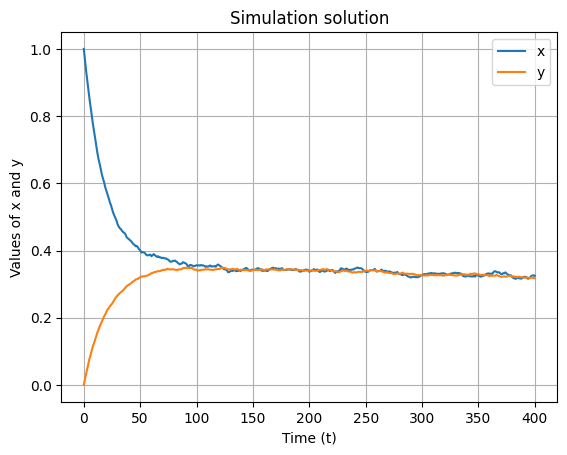

In [6]:
t_max = 400
N=2
M=30


x = np.ones(M)
y = np.zeros(M*2)

#A1,A2 = trade(x,y)

#A1 = np.mean(A1,axis = 1)
#A2 = np.mean(A2,axis = 1)

c=2

if c == 2:
    Data = np.zeros((100,2, t_max+1))
    for i in range(100):
        x = np.ones(M)
        y = np.zeros(M*2)
        A3,A4 = trade(x,y)

        A3 = np.mean(A3,axis = 1)
        A4 = np.mean(A4,axis = 1)

        Data[i, 0, :] = A3  # Store A1 in first row of Data[i]
        Data[i, 1, :] = A4  # Store A2 in second row of Data[i]

    AVG_DATA1 = np.mean(Data[:,0],axis=0)
    AVG_DATA2 = np.mean(Data[:,1],axis=0)
    print(AVG_DATA2.shape)

    plt.plot(AVG_DATA1, label = "x")
    plt.plot(AVG_DATA2, label = "y")
else:
    plt.plot(A1, label = "x")
    plt.plot(A2, label = "y")

plt.xlabel('Time (t)')
plt.ylabel('Values of x and y')
plt.title('Simulation solution')
plt.grid()
plt.legend()
plt.show()


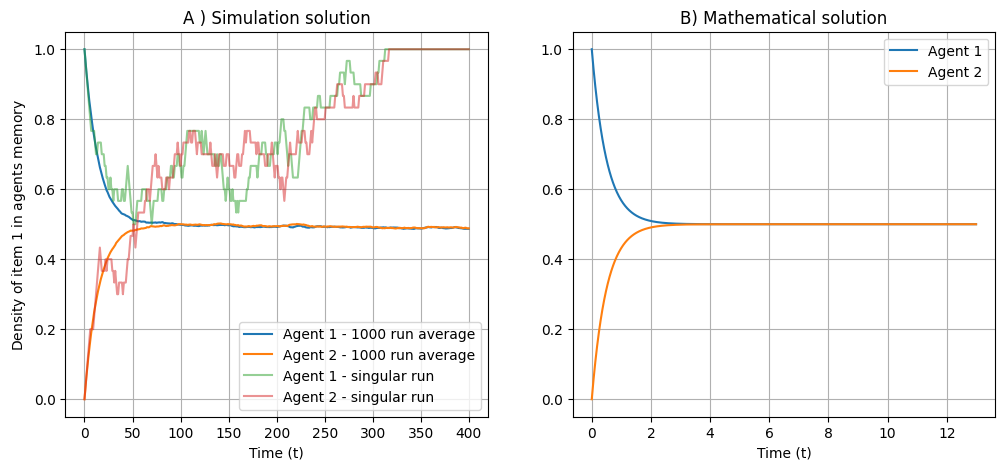

In [106]:
k = np.linspace(0, 400, len(x_vals))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title('A ) Simulation solution')
plt.plot(AVG_DATA1, label = "Agent 1 - 1000 run average")
plt.plot(AVG_DATA2, label = "Agent 2 - 1000 run average")
plt.plot(A1,alpha = 0.5, label = "Agent 1 - singular run")
plt.plot(A2,alpha = 0.5, label = "Agent 2 - singular run")
plt.ylabel(r'Density of item $1$ in agents memory')
plt.grid()
plt.xlabel('Time (t)')
plt.legend()
plt.subplot(1,2,2)
plt.title('B) Mathematical solution')
plt.plot(t_vals, x_vals, label='Agent 1')
plt.plot(t_vals, y_vals, label='Agent 2')
plt.xlabel('Time (t)')


plt.grid()
plt.legend()
plt.show()

In [ ]:
# Sample data
x = np.arange(100)
A1 = np.sin(x / 10) + np.random.normal(scale=0.1, size=len(x))
A2 = np.cos(x / 10) + np.random.normal(scale=0.1, size=len(x))
AVG_DATA1 = np.convolve(A1, np.ones(100)/100, mode='same')
AVG_DATA2 = np.convolve(A2, np.ones(100)/100, mode='same')

# Plotting the actual data
line1, = plt.plot(AVG_DATA1, label="Agent 1 - 1000 run average", color='blue')
line2, = plt.plot(AVG_DATA2, label="Agent 2 - 1000 run average", color='orange')
plt.plot(A1, alpha=0.5, label="Agent 1 - run example", color='blue')
plt.plot(A2, alpha=0.5, label="Agent 2 - run example", color='orange')

# Create custom legend items
custom_legend = [
    Line2D([0], [0], color='blue', lw=2, label='Agent 1'),
    Line2D([0], [0], color='orange', lw=2, label='Agent 2'),
    Line2D([0], [0], color='blue', lw=2, alpha=0.5, label='Agent 1 (example run)'),
    Line2D([0], [0], color='orange', lw=2, alpha=0.5, label='Agent 2 (example run)')
]

# Show custom legend
plt.legend(handles=custom_legend, loc='upper right')
plt.title("Agent Comparison")
plt.xlabel("Episodes")
plt.ylabel("Performance")
plt.show()